In [ ]:
## Analysis of inflow outputs for renal cell carcinoma dataset
## Dr Daniyal Jafree, Lotfollahi Group, CellGen Programme, Wellcome Sanger Institute
## Validation for pertubation experiment - derivation of ICB-like T cell subset with replacement of other T cells within TLS region
## Final Version - 20th July 2025

In [1]:
## Load required packages

import os, sys
import yaml
import mintflow
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
import numpy as np
import anndata
import gc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import mintflow
import mintflow.interface.perturbation.module_gen_micsizefactor
import mintflow.interface.perturbation.module_gen_stdata
import gseapy as gp
from gseapy.plot import barplot


/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/team361/aa36/OnGit/inflow/src/mintflow/utils_pyg.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
## Settings

num_generated_realisations_loop1 = 2 
num_generated_realisations_loop2 = 10 # The multiplier of this and the above gives the total number of realisations

In [3]:
# Choose paths to anndata

path_anndata = '/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/42_Kidney_Rerun_NewSubPopulation/NonGit/Data/inflow_testdata_RCC3_processed_5K.h5ad'  
# TODO:MODIFY: set to the path where you've put the `.h5ad` file that you downloaded above.

path_checkpoint = '/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/42_Kidney_Rerun_NewSubPopulation/NonGit/PathOutput/Jul9th_kidney_0.01_0.01/checkpoint_epoch_14.pt'  
# TODO:MODIFY: set to the path where you've put the `.pt` file that you downloaded above.

In [4]:
ls /nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/42_Kidney_Rerun_NewSubPopulation/NonGit/PathOutput/Jul9th_kidney_0.1_0.1/ -lhst

total 1.3T
 40G -rw-r--r-- 1 aa36 team361  30G Jul 11 15:12 checkpoint_epoch_49.pt
 11G -rw-r--r-- 1 aa36 team361 7.6G Jul 11 15:09 df_evaluation_result_epoch_49.pkl
8.3G -rw-r--r-- 1 aa36 team361 6.2G Jul 11 14:52 predictions_epoch_49.pkl
 40G -rw-r--r-- 1 aa36 team361  30G Jul 11 14:14 checkpoint_epoch_48.pt
 11G -rw-r--r-- 1 aa36 team361 7.6G Jul 11 14:11 df_evaluation_result_epoch_48.pkl
8.3G -rw-r--r-- 1 aa36 team361 6.2G Jul 11 13:54 predictions_epoch_48.pkl
 40G -rw-r--r-- 1 aa36 team361  30G Jul 11 13:17 checkpoint_epoch_47.pt
 11G -rw-r--r-- 1 aa36 team361 7.6G Jul 11 13:14 df_evaluation_result_epoch_47.pkl
8.3G -rw-r--r-- 1 aa36 team361 6.2G Jul 11 12:57 predictions_epoch_47.pkl
 40G -rw-r--r-- 1 aa36 team361  30G Jul 11 12:19 checkpoint_epoch_46.pt
 11G -rw-r--r-- 1 aa36 team361 7.6G Jul 11 12:16 df_evaluation_result_epoch_46.pkl
8.3G -rw-r--r-- 1 aa36 team361 6.2G Jul 11 11:59 predictions_epoch_46.pkl
 40G -rw-r--r-- 1 aa36 team361  30G Jul 11 11:21 checkpoint_epoch_45.pt
 

In [5]:
# Shows if GPU is available or not

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [6]:
# Load checkpoint

checkpoint_mintflow = torch.load(
    path_checkpoint,
    map_location='cpu',
    weights_only=False
)
checkpoint_mintflow['model'].to(device)
print("Loaded the checkpoint.")

Loaded the checkpoint.


AnnData object with n_obs × n_vars = 71104 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'level_2_cell_type_formintflow', 'TissueSectionID_for_MintFlow', 'batchID_for_MintFlow'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'X_by_Dan'


/tmp/ipykernel_3710465/1411955818.py:28: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


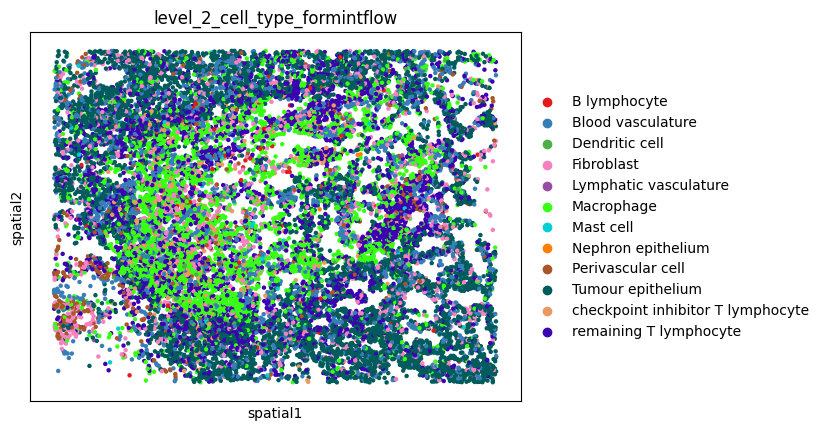

In [7]:
### GENERATES FIGURE 7B

# Set tissue boundaries and colours

adata = sc.read_h5ad(
    path_anndata
)
adata_original = adata[
    (adata.obs['x_centroid'] > 1500) &  (adata.obs['x_centroid'] < 3500) &\
    (adata.obs['y_centroid'] > 1000) &  (adata.obs['y_centroid'] < 2500)
].copy()
print(adata)

# Define your custom colors
custom_colors = {
    'B lymphocyte': '#e41a1c',              # red
    'Blood vasculature': '#377eb8',         # blue
    'Dendritic cell': '#4daf4a',            # green
    'Fibroblast': '#f781bf',                # pink
    'Lymphatic vasculature': '#984ea3',     # purple (maroon)
    'Macrophage': '#39ff14',                # 💡 fluorescent green (neon/lime)
    'Mast cell': '#00ced1',                 # turquoise
    'Nephron epithelium': '#ff7f00',        # orange
    'Perivascular cell': '#a65628',         # brown
    'checkpoint inhibitor T lymphocyte': '#ea9a61',  # peach-orange
    'remaining T lymphocyte': '#3b00b2',    # dark blue
    'Tumour epithelium': '#005c5c'          # dark teal-green
}


# Plot using your custom color mapping
sc.pl.spatial(
    adata_original,
    spot_size=20,
    color='level_2_cell_type_formintflow',
    palette=custom_colors
)

In [8]:
# Replace T cells

adata_perturbed = adata_original.copy()
adata_perturbed.obs['level_2_cell_type_formintflow'] = adata_perturbed.obs['level_2_cell_type_formintflow'].replace(
    {'remaining T lymphocyte':'checkpoint inhibitor T lymphocyte'}
) 


/tmp/ipykernel_3710465/2819558733.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_perturbed.obs['level_2_cell_type_formintflow'] = adata_perturbed.obs['level_2_cell_type_formintflow'].replace(


/tmp/ipykernel_3710465/2726631079.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


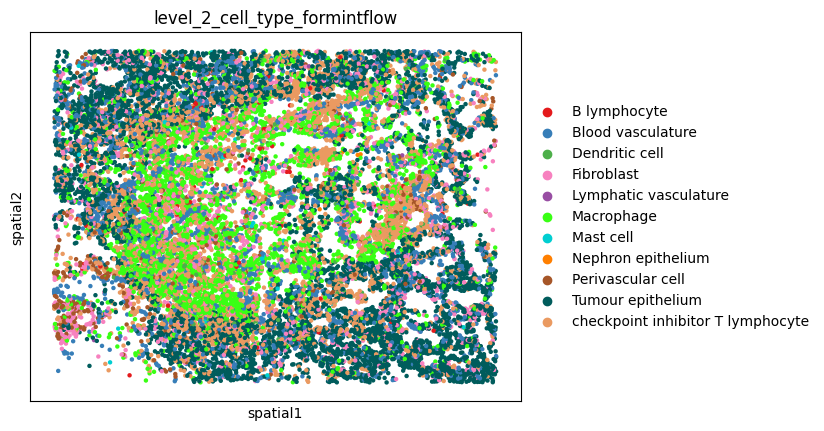

In [9]:
### GENERATES FIGURE 7B
# Show effect on spatial plot

sc.pl.spatial(
    adata_perturbed,
    spot_size=20,
    color='level_2_cell_type_formintflow',
    palette=custom_colors
)

In [11]:
# Check pertubation has worked

adata_perturbed.obs['level_2_cell_type_formintflow'].value_counts()

level_2_cell_type_formintflow
Tumour epithelium                    5039
checkpoint inhibitor T lymphocyte    4296
Macrophage                           2921
Blood vasculature                    2460
Fibroblast                           1378
Perivascular cell                     406
Dendritic cell                        238
B lymphocyte                           84
Mast cell                              34
Lymphatic vasculature                   8
Nephron epithelium                      5
Name: count, dtype: int64

In [13]:
## Create neighbourhood graphs

kwargs_neighbourhood_graph = {
    'spatial_key': 'spatial',
    'library_key': None,
    'set_diag': False,
    'delaunay': False,
    'n_neighs': 10
}
adata_original.uns = {}
adata_perturbed.uns = {}

sq.gr.spatial_neighbors(
    adata=adata_original,
    **kwargs_neighbourhood_graph
)
sq.gr.spatial_neighbors(
    adata=adata_perturbed,
    **kwargs_neighbourhood_graph
)

In [14]:
# Print checkpoint

print(checkpoint_mintflow['data_mintflow']['train_list_tissue_section'].map_Batchname_to_inflowBatchID)

{'adata1': 'inflow_BatchID_0', 'adata2': 'inflow_BatchID_1', 'adata3': 'inflow_BatchID_2', 'adata4': 'inflow_BatchID_3'}


In [15]:
# Show batches

adata_original.obs['batch']

5        adata3
9        adata3
10       adata3
19       adata3
20       adata3
          ...  
77556    adata3
77558    adata3
77561    adata3
77581    adata3
77589    adata3
Name: batch, Length: 16869, dtype: category
Categories (1, object): ['adata3']

In [16]:
# Double check path to anndata

path_anndata

'/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/42_Kidney_Rerun_NewSubPopulation/NonGit/Data/inflow_testdata_RCC3_processed_5K.h5ad'

In [17]:
# Check path

checkpoint_mintflow['dict_all4_configs']['config_data_train'][2]  # RCC3 is the 3rd anndata --> batch index=2 is correct.

{'file': './NonGit/Data/inflow_testdata_RCC3_processed_5K.h5ad',
 'obskey_cell_type': 'level_2_cell_type_formintflow',
 'obskey_sliceid_to_checkUnique': 'batch',
 'obskey_x': 'x_centroid',
 'obskey_y': 'y_centroid',
 'obskey_biological_batch_key': 'batch',
 'config_neighbourhood_graph': {'n_neighs': 10,
  'set_diag': False,
  'delaunay': False},
 'config_dataloader_train': {'num_neighbors': 5,
  'width_window': 650,
  'min_numpoints_ingrid': 10},
 'config_sq_pl_spatial_scatter': {'edges_width': 0.1,
  'legend_fontsize': 5,
  'figsize': [10, 10],
  'size': 10.0},
 'batchsize_compute_NCC': 10}

In [18]:
gc.collect()
gc.collect()
gc.collect()

0

In [19]:
# Generate realisation for original object

original_MintFLow_Generated_Xmic = 0.0
for index_loop1 in tqdm(range(num_generated_realisations_loop1)):
    result_generation_original = mintflow.generate_insilico_ST_data(
        adata=adata_original,
        obskey_celltype='level_2_cell_type_formintflow',
        obspkey_neighbourhood_graph='spatial_connectivities',
        device=device,
        batch_index_trainingdata=2,
        num_generated_realisations=num_generated_realisations_loop2,
        model=checkpoint_mintflow['model'],
        data_mintflow=checkpoint_mintflow['data_mintflow'],
        dict_all4_configs=checkpoint_mintflow['dict_all4_configs'],
        estimate_spatial_sizefactors_on_sections=[2]
    )
    original_MintFLow_Generated_Xmic = original_MintFLow_Generated_Xmic + np.stack(
        [realisation['MintFLow_Generated_Xmic'] for realisation in result_generation_original['list_generated_realisations_ie_expressions']]
    ).mean(0)

    if index_loop1 != (num_generated_realisations_loop1-1):  # i.e. keep it in the last loop.
        del result_generation_original
    
    gc.collect()
    gc.collect()
    gc.collect()

original_MintFLow_Generated_Xmic = original_MintFLow_Generated_Xmic / (num_generated_realisations_loop1 + 0.0)

adata_original.obsm['MintFLow_Generated_Xmic'] = original_MintFLow_Generated_Xmic
print("Done!")

  0%|          | 0/2 [00:00<?, ?it/s]

Evaluating on tissue section: 2:   0%|          | 0/59 [00:00<?, ?it/s]

Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/nfs/team361/aa36/OnGit/inflow/src/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),


Evaluating on tissue section: 2:   0%|          | 0/59 [00:00<?, ?it/s]

Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/nfs/team361/aa36/OnGit/inflow/src/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),


Done!


In [20]:
gc.collect()
gc.collect()
gc.collect()

0

In [21]:
# Generate realisation for perturbed object

perturbed_MintFLow_Generated_Xmic = 0.0
for index_loop1 in tqdm(range(num_generated_realisations_loop1)):
    result_generation_perturbed = mintflow.generate_insilico_ST_data(
        adata=adata_perturbed,
        obskey_celltype='level_2_cell_type_formintflow',
        obspkey_neighbourhood_graph='spatial_connectivities',
        device=device,
        batch_index_trainingdata=2,
        num_generated_realisations=num_generated_realisations_loop2,
        model=checkpoint_mintflow['model'],
        data_mintflow=checkpoint_mintflow['data_mintflow'],
        dict_all4_configs=checkpoint_mintflow['dict_all4_configs'],
        estimate_spatial_sizefactors_on_sections=[2]
    )
    perturbed_MintFLow_Generated_Xmic = perturbed_MintFLow_Generated_Xmic + np.stack(
        [realisation['MintFLow_Generated_Xmic'] for realisation in result_generation_perturbed['list_generated_realisations_ie_expressions']]
    ).mean(0)

    if index_loop1 != (num_generated_realisations_loop1-1):  # i.e. keep it in the last loop.
        del result_generation_perturbed
    
    gc.collect()
    gc.collect()
    gc.collect()

perturbed_MintFLow_Generated_Xmic = perturbed_MintFLow_Generated_Xmic / (num_generated_realisations_loop1 + 0.0)
adata_perturbed.obsm['MintFLow_Generated_Xmic'] = perturbed_MintFLow_Generated_Xmic
print("Done!")

  0%|          | 0/2 [00:00<?, ?it/s]

Evaluating on tissue section: 2:   0%|          | 0/59 [00:00<?, ?it/s]

Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/nfs/team361/aa36/OnGit/inflow/src/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),


Evaluating on tissue section: 2:   0%|          | 0/59 [00:00<?, ?it/s]

Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/nfs/team361/aa36/OnGit/inflow/src/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),


Done!


In [22]:
gc.collect()
gc.collect()
gc.collect()

0

In [23]:
# Create dictionary of ids of altered cells

list_cellID_original = adata_original.obs['cell_id'].tolist()
list_cellID_perturbed = adata_perturbed.obs['cell_id'].tolist()

dict_cellID_to_indexOriginal = {
    cell_id: list_cellID_original.index(cell_id)
    for cell_id in set(adata_original.obs['cell_id']).union(set(adata_perturbed.obs['cell_id']))
}
dict_cellID_to_indexPerturbed = {
    cell_id: list_cellID_perturbed.index(cell_id)
    for cell_id in set(adata_original.obs['cell_id']).union(set(adata_perturbed.obs['cell_id']))
}

In [24]:
# Check

print(adata_original.obs['cell_id'])
print(adata_perturbed.obs['cell_id'])

5        aaaeaefn-1
9        aaafcepf-1
10       aaaffhig-1
19       aaamcehi-1
20       aaanicin-1
            ...    
77556    oienhmde-1
77558    oieokhjh-1
77561    oifbejfe-1
77581    oifobbke-1
77589    oigdgphf-1
Name: cell_id, Length: 16869, dtype: category
Categories (16869, object): ['aaaeaefn-1', 'aaafcepf-1', 'aaaffhig-1', 'aaamcehi-1', ..., 'oieokhjh-1', 'oifbejfe-1', 'oifobbke-1', 'oigdgphf-1']
5        aaaeaefn-1
9        aaafcepf-1
10       aaaffhig-1
19       aaamcehi-1
20       aaanicin-1
            ...    
77556    oienhmde-1
77558    oieokhjh-1
77561    oifbejfe-1
77581    oifobbke-1
77589    oigdgphf-1
Name: cell_id, Length: 16869, dtype: category
Categories (16869, object): ['aaaeaefn-1', 'aaafcepf-1', 'aaaffhig-1', 'aaamcehi-1', ..., 'oieokhjh-1', 'oifbejfe-1', 'oifobbke-1', 'oigdgphf-1']


In [25]:
# Only include cells where MCC has changes

dict_cellID_to_MCChaschanged = {}
for cell_id in set(adata_original.obs['cell_id'].tolist()).union(set(adata_perturbed.obs['cell_id'].tolist())):
    if (cell_id not in adata_original.obs['cell_id'].tolist()) or (cell_id not in adata_perturbed.obs['cell_id'].tolist()):
         # if the cell is dropped or added during perturbation --> No differential expression on it
        dict_cellID_to_MCChaschanged[cell_id] = False
    else:
        dict_cellID_to_MCChaschanged[cell_id] = not np.allclose(
            result_generation_original['np_MCC'][dict_cellID_to_indexOriginal[cell_id]],
            result_generation_perturbed['np_MCC'][dict_cellID_to_indexPerturbed[cell_id]]
        ) # BUGBUGBUGBUG: it must be `not np.allclose` :|        

In [26]:
print("For {} percent of cells, the MCC has changed due to perturbation.".format(
    np.round(
        100.0 * np.mean([v for u, v in dict_cellID_to_MCChaschanged.items()]),
        3
    )
))

For 84.67 percent of cells, the MCC has changed due to perturbation.


In [27]:
# SAVE DATASETS

# adata_original.write("/nfs/team361/dj17/MintFlowPertubation_Tcellvalidation/outputs_v1/adata_original.h5ad")
# adata_perturbed.write("/nfs/team361/dj17/MintFlowPertubation_Tcellvalidation/outputs_v1/adata_perturbed.h5ad")


In [28]:
# LOAD DATASETS

#adata_original = sc.read_h5ad("/nfs/team361/dj17/MintFlowPertubation_Tcellvalidation/outputs_v1/adata_original.h5ad")
#adata_perturbed = sc.read_h5ad("/nfs/team361/dj17/MintFlowPertubation_Tcellvalidation/outputs_v1/adata_perturbed.h5ad")

In [29]:
gc.collect()
gc.collect()
gc.collect()

0

In [30]:
print(adata_original)
print(adata_perturbed)

AnnData object with n_obs × n_vars = 16869 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'level_2_cell_type_formintflow', 'TissueSectionID_for_MintFlow', 'batchID_for_MintFlow'
    uns: 'spatial_neighbors'
    obsm: 'X_scVI', 'X_umap', 'spatial', 'MintFLow_Generated_Xmic'
    layers: 'X_by_Dan'
    obsp: 'spatial_connectivities', 'spatial_distances'
AnnData object with n_obs × n_vars = 1686

In [31]:
# Shows how many cells are filtered

for ct in set(adata_perturbed.obs['level_2_cell_type_formintflow']):
    row_filter_original = np.logical_and(
        np.array(adata_original.obs['level_2_cell_type_formintflow']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_original.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    row_filter_perturbed = np.logical_and(
        np.array(adata_perturbed.obs['level_2_cell_type_formintflow']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_perturbed.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    print("For cell type {} filtered {} cells from orig and {} cells from modif.".format(ct, np.sum(row_filter_original), np.sum(row_filter_perturbed)))

For cell type Perivascular cell filtered 324 cells from orig and 324 cells from modif.
For cell type Blood vasculature filtered 1995 cells from orig and 1995 cells from modif.
For cell type Macrophage filtered 2627 cells from orig and 2627 cells from modif.
For cell type checkpoint inhibitor T lymphocyte filtered 483 cells from orig and 3990 cells from modif.
For cell type Dendritic cell filtered 233 cells from orig and 233 cells from modif.
For cell type Lymphatic vasculature filtered 7 cells from orig and 7 cells from modif.
For cell type Fibroblast filtered 1108 cells from orig and 1108 cells from modif.
For cell type Nephron epithelium filtered 4 cells from orig and 4 cells from modif.
For cell type B lymphocyte filtered 79 cells from orig and 79 cells from modif.
For cell type Tumour epithelium filtered 3888 cells from orig and 3888 cells from modif.
For cell type Mast cell filtered 28 cells from orig and 28 cells from modif.


/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


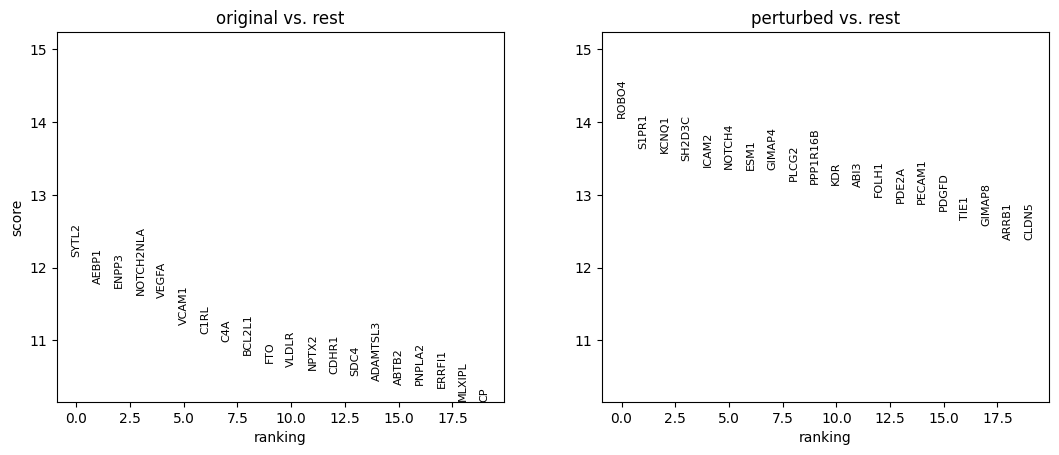

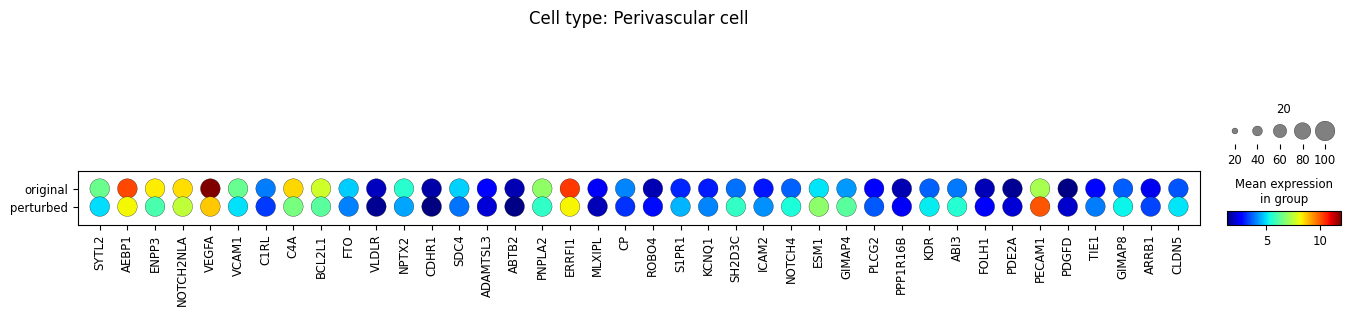

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


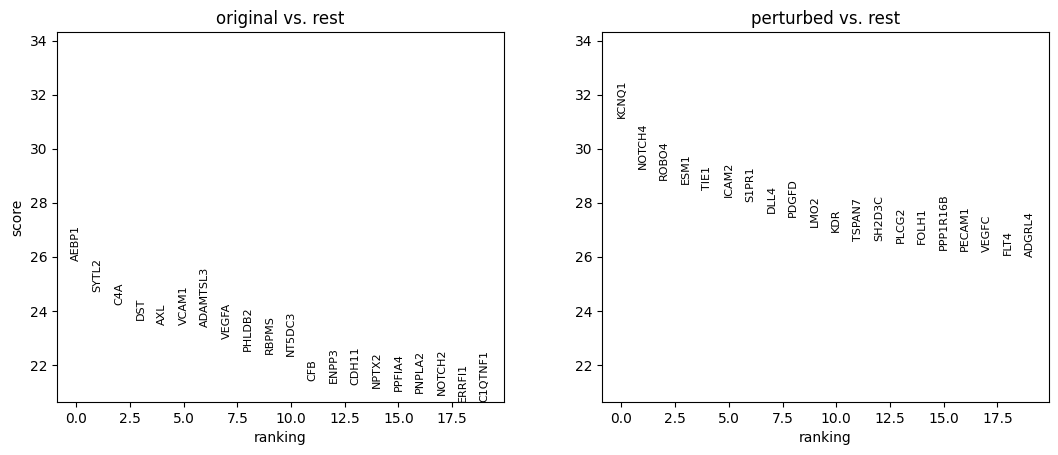

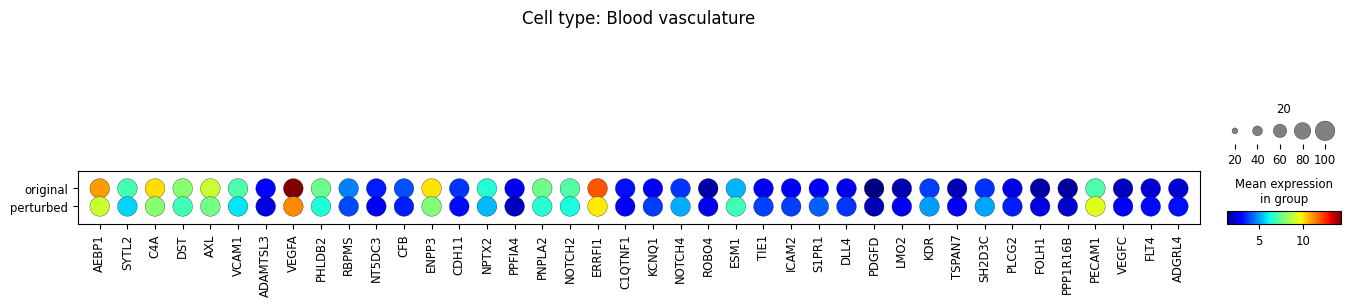

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


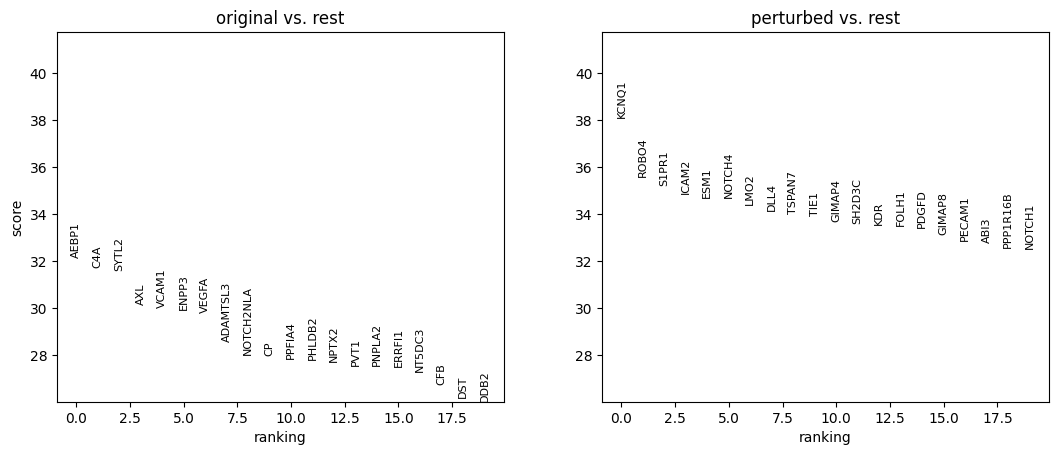

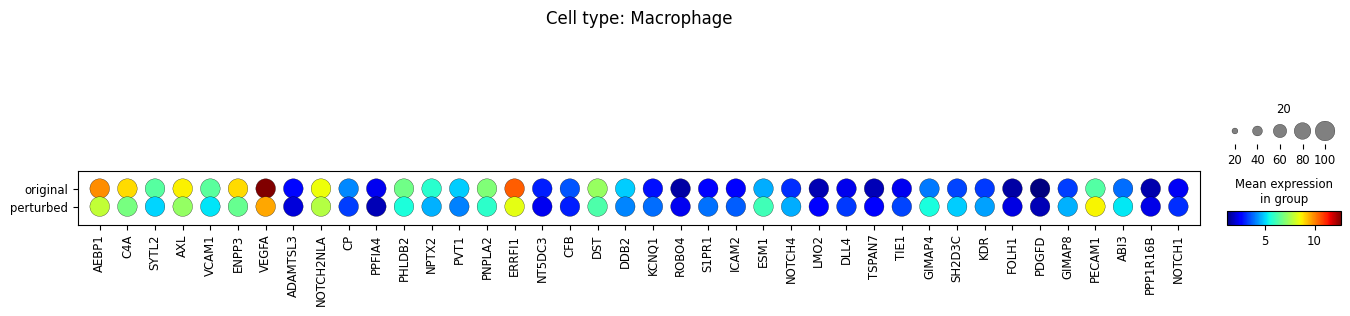

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


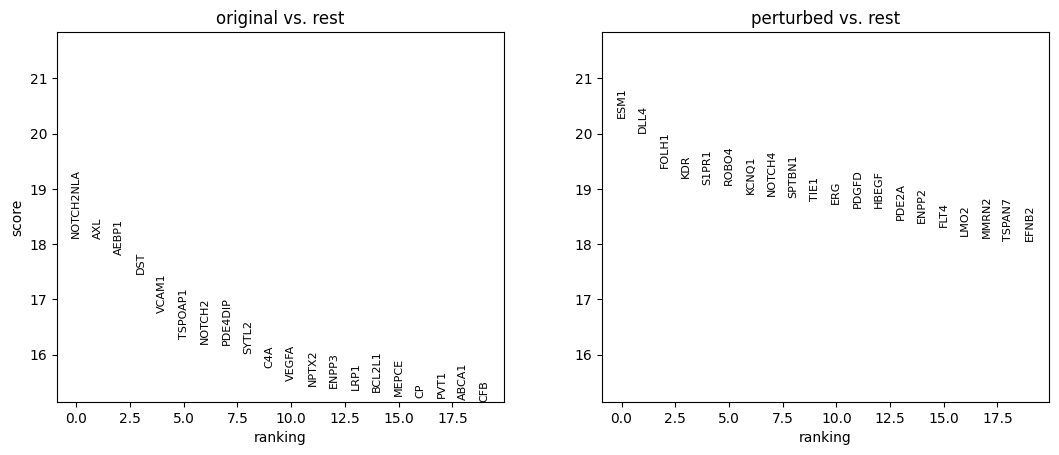

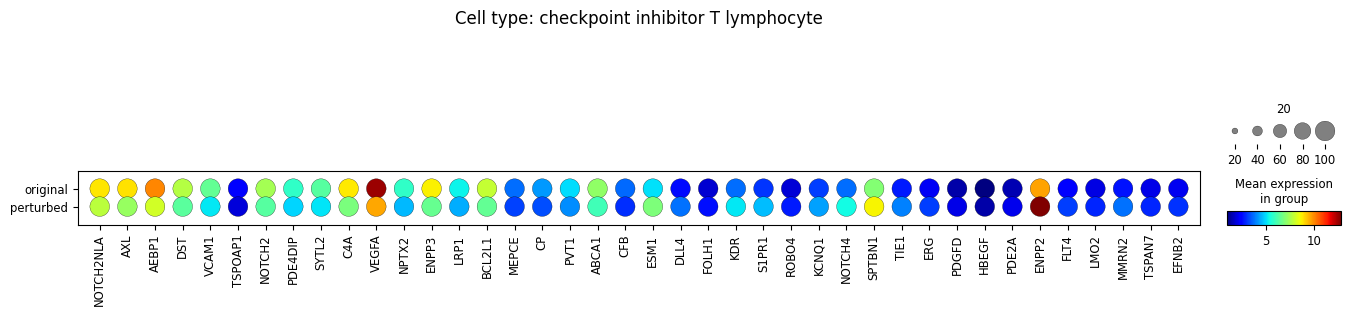

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


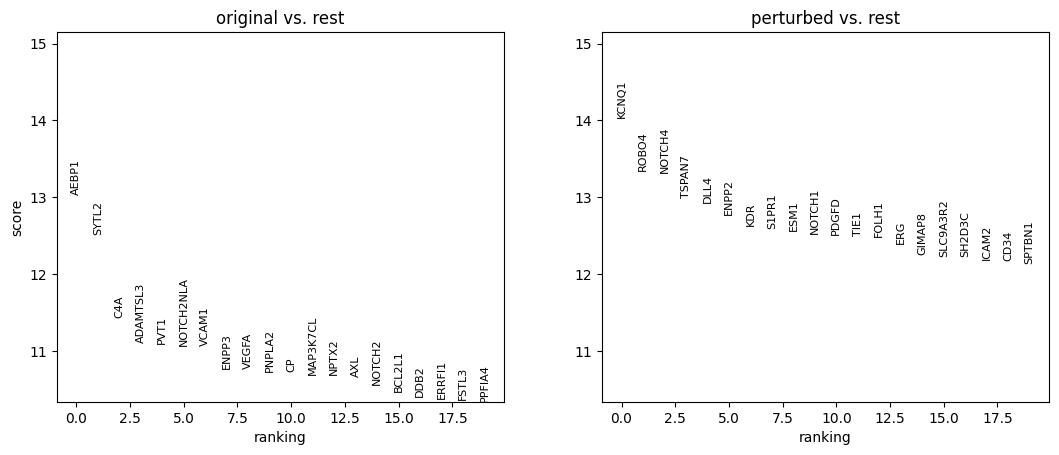

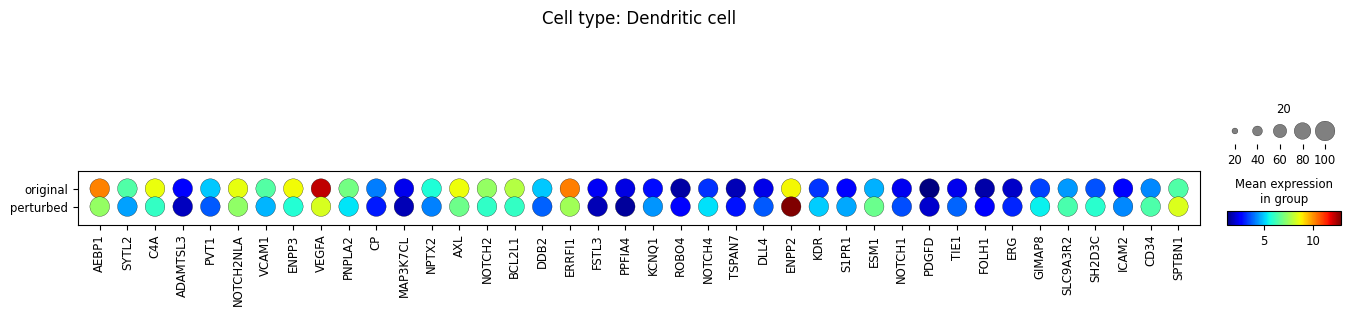

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


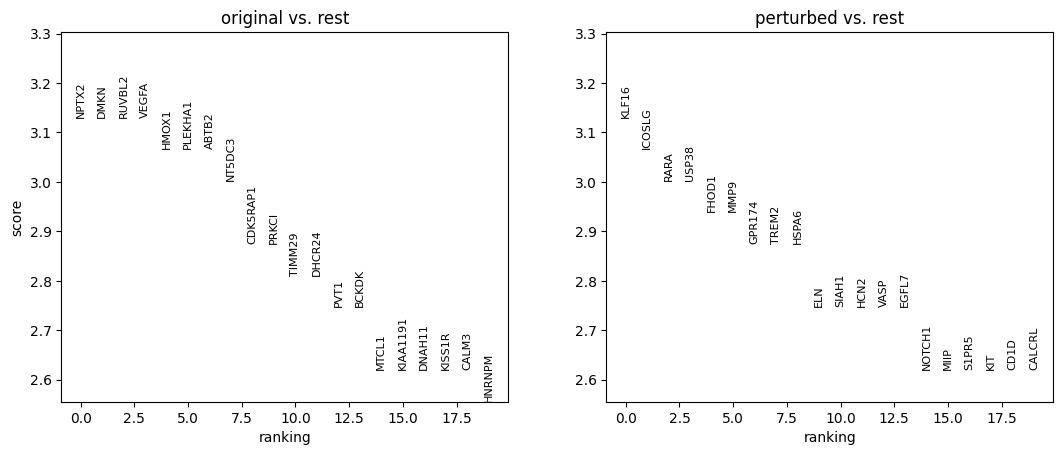

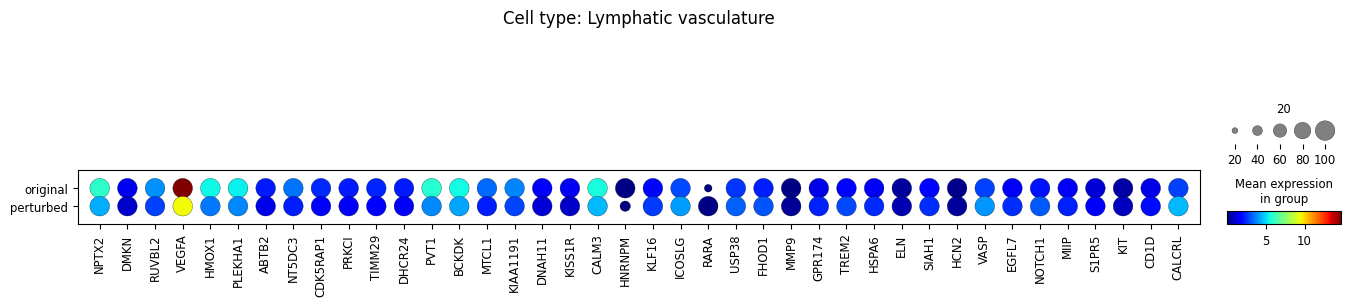

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


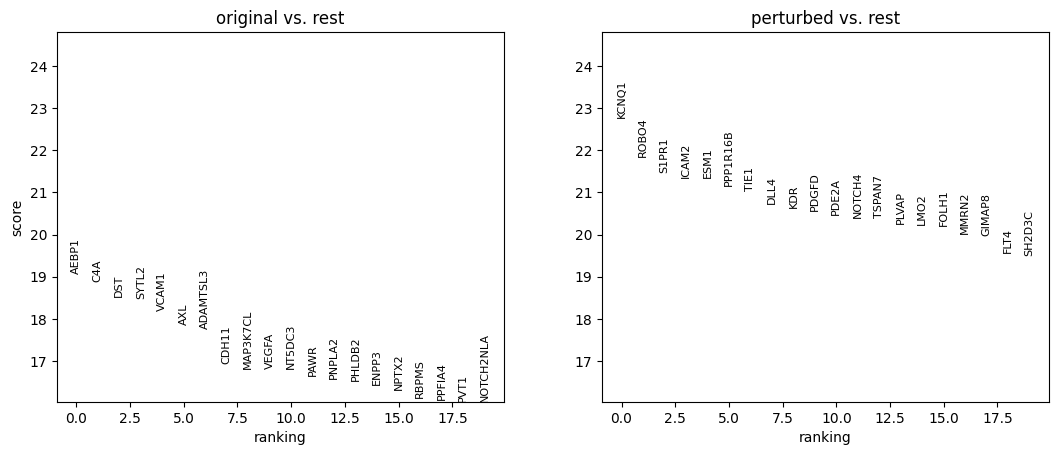

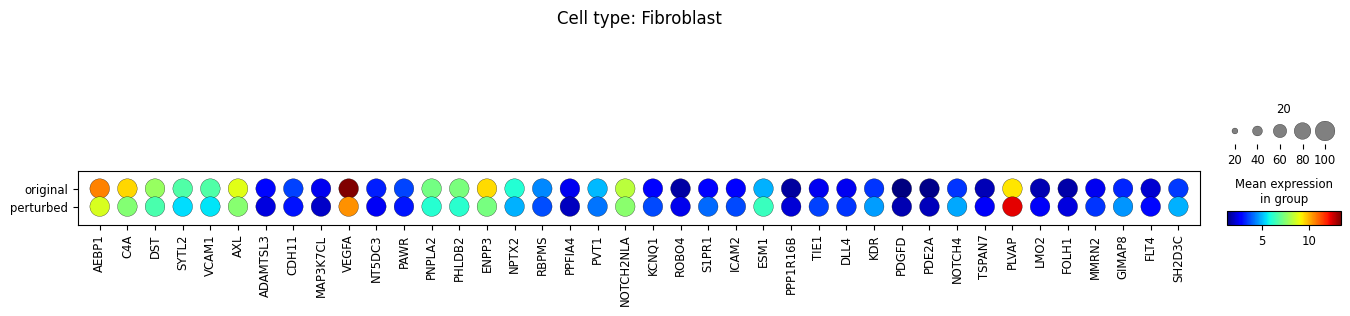

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/scanpy/plotting/_tools/__init__.py:490: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs[0].set_ylim(ymin, ymax)


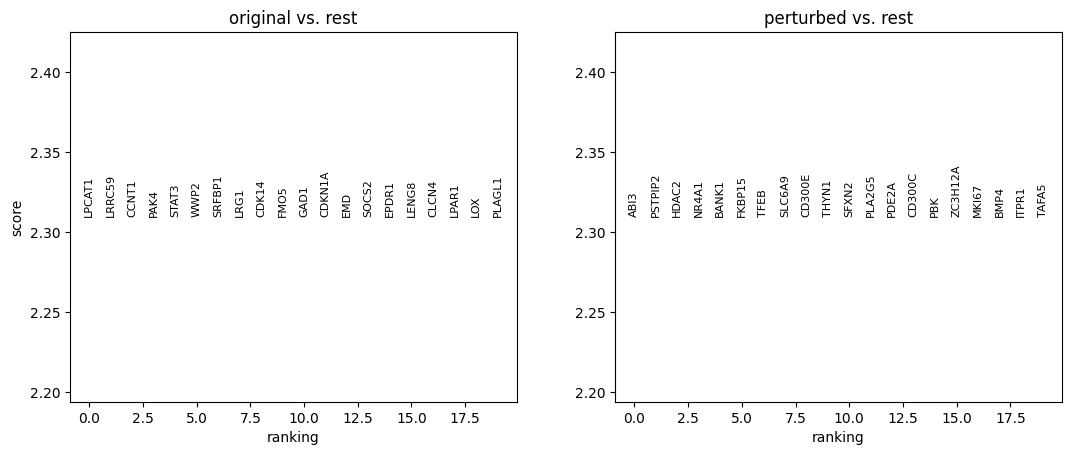

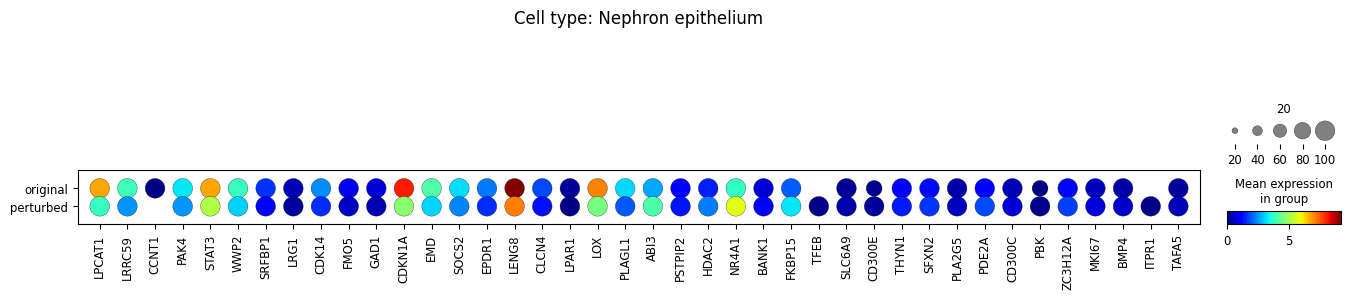

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


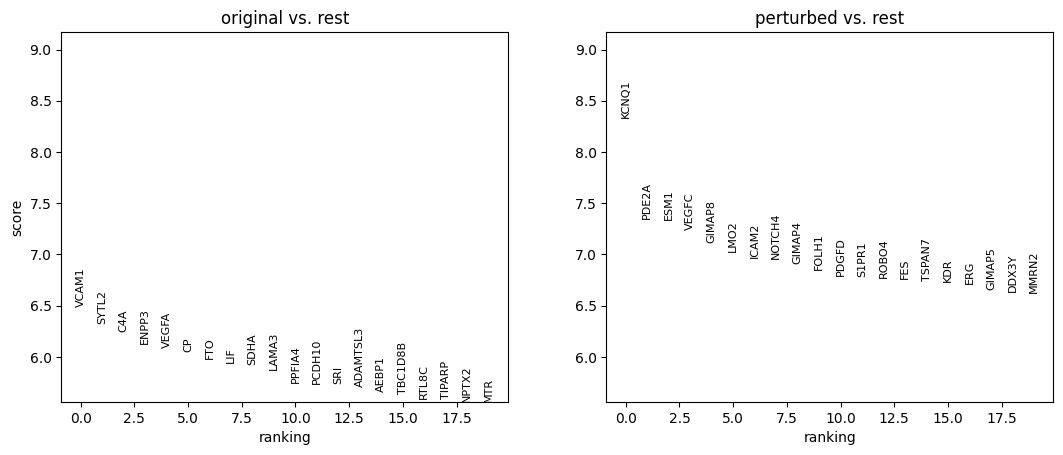

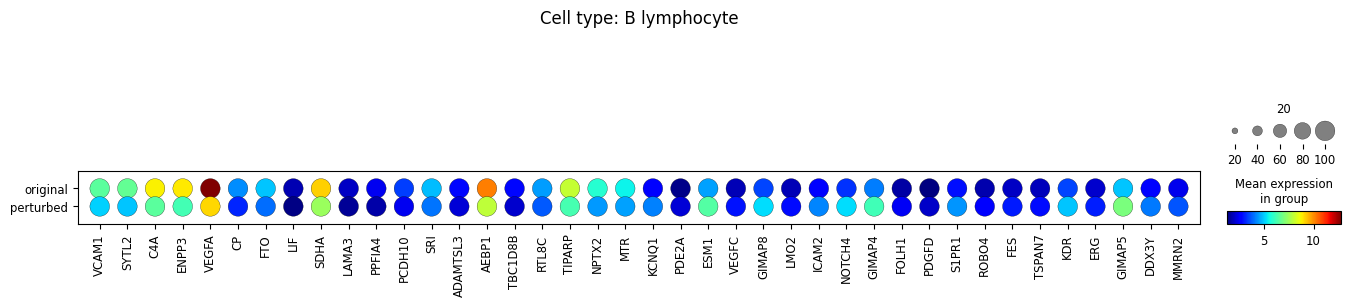

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


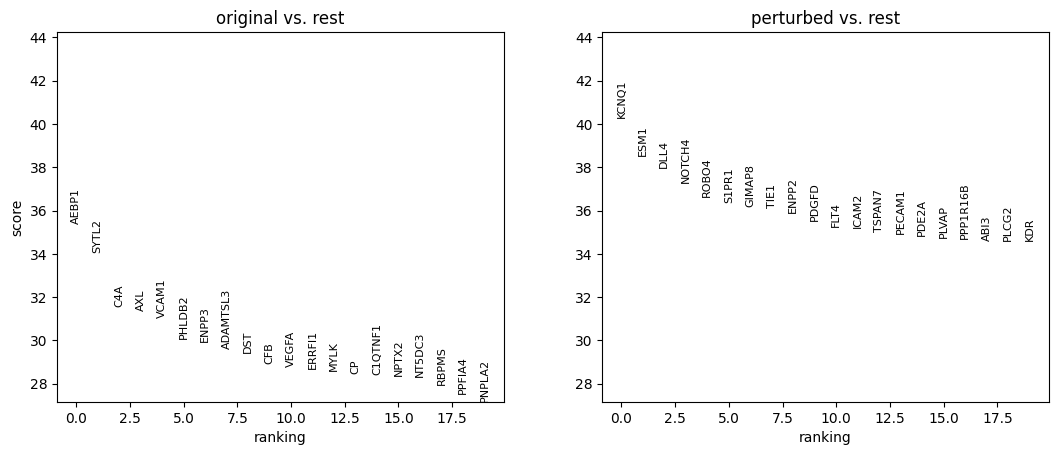

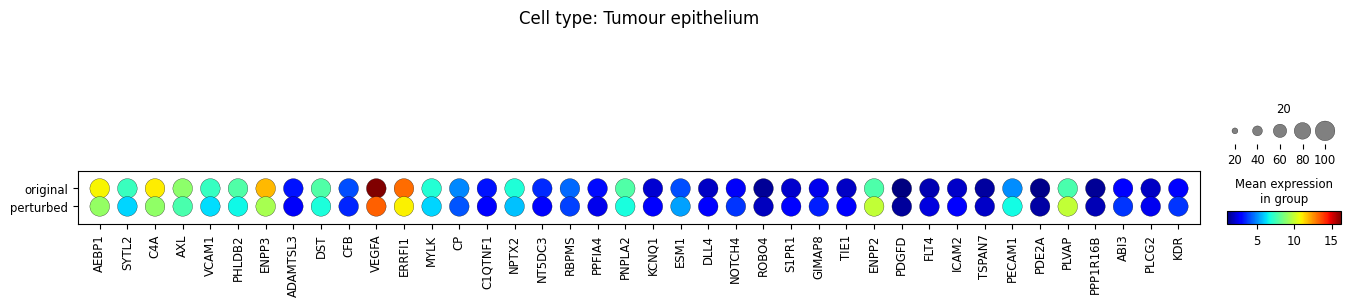

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


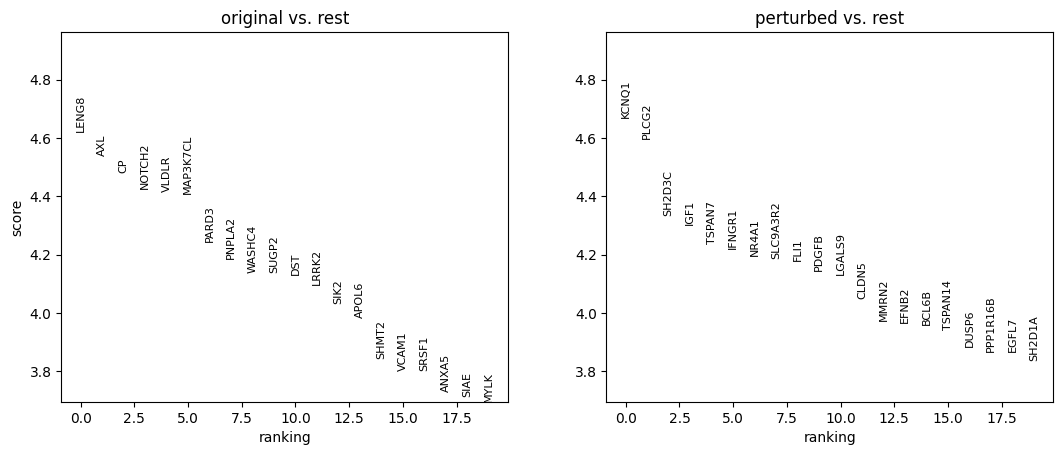

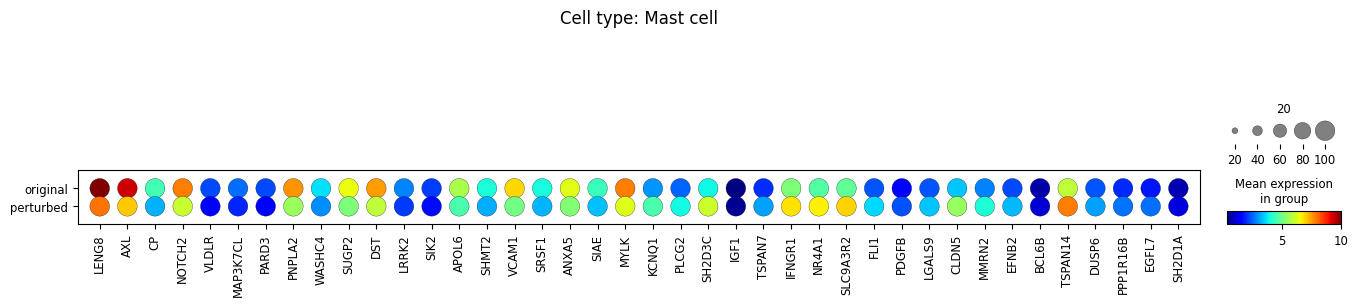

In [33]:
# Akbar version of differential expression testing

for ct in set(adata_perturbed.obs['level_2_cell_type_formintflow']):
    row_filter_original = np.logical_and(
        np.array(adata_original.obs['level_2_cell_type_formintflow']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_original.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    row_filter_perturbed = np.logical_and(
        np.array(adata_perturbed.obs['level_2_cell_type_formintflow']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_perturbed.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    
    

    if np.sum(np.logical_and(row_filter_original, row_filter_perturbed)) <= 2:
        continue  # not enough cells --> skip the DE analysis

    # make an anndata for DE analysis
    adata_DEanalysis = sc.AnnData(
        X=np.concatenate(
            [adata_original.obsm['MintFLow_Generated_Xmic'][row_filter_original.tolist()] + 0.0,
             adata_perturbed.obsm['MintFLow_Generated_Xmic'][row_filter_perturbed.tolist()] + 0.0],
            0
        ),
        obs=pd.DataFrame(
            data=np.array(
                [sum(row_filter_original)*['original'] +\
                 sum(row_filter_perturbed)*['perturbed']]
            ).T,
            columns=['original_vs_perturbed']
        ),
        var=adata_original.var
    )


    # perform the DE analysis
    adata_DEanalysis.layers['xspl_before_log1p'] = adata_DEanalysis.X.copy()
    sc.pp.log1p(adata_DEanalysis)

    sc.tl.rank_genes_groups(
        adata_DEanalysis,
        'original_vs_perturbed',
        method='wilcoxon',
        n_genes=20
    )
    sc.pl.rank_genes_groups(adata_DEanalysis)
    sc.pl.dotplot(
        adata_DEanalysis,
        var_names=\
        [u[0] for u in adata_DEanalysis.uns['rank_genes_groups']['names'].tolist()]+\
        [u[1] for u in adata_DEanalysis.uns['rank_genes_groups']['names'].tolist()],
        groupby='original_vs_perturbed',
        dendrogram=True,
        title="Cell type: {}".format(ct),
        size_title=20,
        cmap='jet',
        layer='xspl_before_log1p',
        mean_only_expressed=True
    )

⚠️ Warning: these genes were not found and will be skipped: {'CLEC4E', 'NAPSB', 'SECTM1', 'ANKRD22', 'SIGLEC10', 'IGSF6', 'ADORA3FGL2', 'CALHM6', 'MNDA', 'HLA-DQB2', 'TMIGD3'}


/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


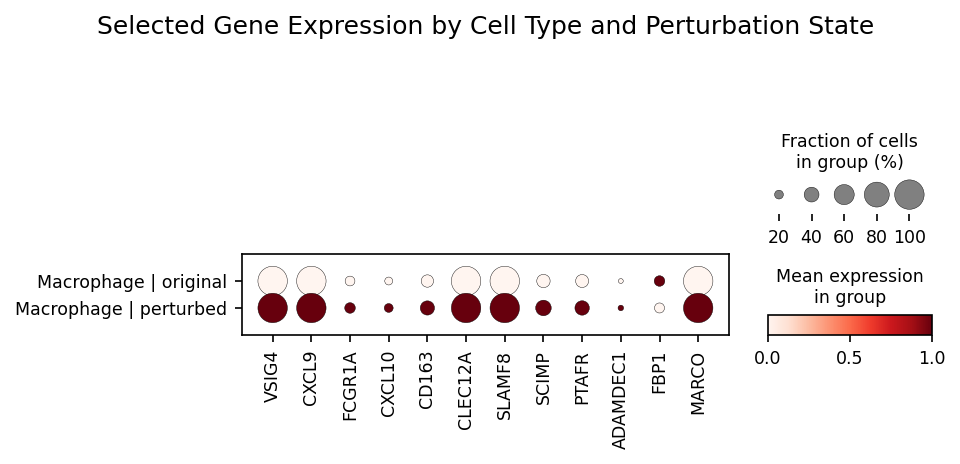

In [70]:
# 🔧 Step 1: Choose cell types and genes of interest
selected_cell_types = ['Macrophage']
selected_genes = ['VSIG4', 'CXCL9', 'SIGLEC10', 'FCGR1A', 'TMIGD3', 'NAPSB', 'CXCL10',
    'CALHM6', 'CD163', 'CLEC12A', 'SECTM1', 'SLAMF8', 'SCIMP',
    'CLEC4E', 'PTAFR', 'MNDA', 'ADORA3' 'FGL2', 'HLA-DQB2', 'ADAMDEC1', 'FBP1', 'ANKRD22', 'MARCO', 'IGSF6'
]

# 🔁 Step 2: Loop and build filtered data
X_data = []
perturbation_labels = []
cell_type_labels = []

for ct in selected_cell_types:
    row_filter_original = np.logical_and(
        adata_original.obs['level_2_cell_type_formintflow'] == ct,
        np.array([
            dict_cellID_to_MCChaschanged.get(cell_id, False)
            for cell_id in adata_original.obs['cell_id'].tolist()
        ])
    )

    row_filter_perturbed = np.logical_and(
        adata_perturbed.obs['level_2_cell_type_formintflow'] == ct,
        np.array([
            dict_cellID_to_MCChaschanged.get(cell_id, False)
            for cell_id in adata_perturbed.obs['cell_id'].tolist()
        ])
    )

    if np.sum(row_filter_original) < 2 or np.sum(row_filter_perturbed) < 2:
        continue

    # Add original cells
    X_data.append(adata_original.obsm['MintFLow_Generated_Xmic'][row_filter_original.tolist()] + 0.0)
    perturbation_labels.extend(['original'] * np.sum(row_filter_original))
    cell_type_labels.extend([ct] * np.sum(row_filter_original))

    # Add perturbed cells
    X_data.append(adata_perturbed.obsm['MintFLow_Generated_Xmic'][row_filter_perturbed.tolist()] + 0.0)
    perturbation_labels.extend(['perturbed'] * np.sum(row_filter_perturbed))
    cell_type_labels.extend([ct] * np.sum(row_filter_perturbed))

# ✅ Step 3: Create AnnData
adata_DEanalysis = sc.AnnData(
    X=np.concatenate(X_data, axis=0),
    obs=pd.DataFrame({
        'perturbation_state': perturbation_labels,
        'cell_type': cell_type_labels
    }),
    var=adata_original.var.copy()
)

# Step 4: Add combined label for plotting
adata_DEanalysis.obs['celltype_condition'] = (
    adata_DEanalysis.obs['cell_type'] + " | " + adata_DEanalysis.obs['perturbation_state']
)

# ✅ Step 5: Filter genes to those that exist
genes_to_plot = [g for g in selected_genes if g in adata_DEanalysis.var_names]

# 🚨 Warn if any selected genes are missing
missing_genes = set(selected_genes) - set(genes_to_plot)
if missing_genes:
    print(f"⚠️ Warning: these genes were not found and will be skipped: {missing_genes}")

# ✅ Step 6: Plot
sc.pl.dotplot(
    adata_DEanalysis,
    var_names=genes_to_plot,
    groupby='celltype_condition',
    standard_scale='var',
    layer=None,  # or 'xspl_before_log1p' if you've logged elsewhere
    cmap='Reds',
    title='Selected Gene Expression by Cell Type and Perturbation State'
)

⚠️ These genes were not found: {'CLEC4E', 'NAPSB', 'SECTM1', 'ANKRD22', 'SIGLEC10', 'IGSF6', 'ADORA3FGL2', 'CALHM6', 'MNDA', 'HLA-DQB2', 'TMIGD3'}
original: mean = 0.603, std = 0.134, n = 2627
perturbed: mean = 0.707, std = 0.157, n = 2627


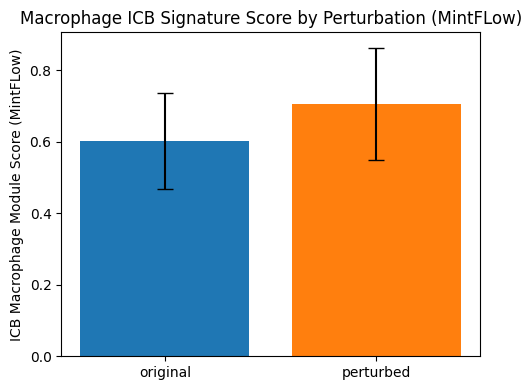

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Define ICB macrophage gene signature
macrophage_genes = ['VSIG4', 'CXCL9', 'SIGLEC10', 'FCGR1A', 'TMIGD3', 'NAPSB', 'CXCL10',
    'CALHM6', 'CD163', 'ASCL2', 'CLEC12A', 'SECTM1', 'SLAMF8', 'SCIMP',
    'CLEC4E', 'PTAFR', 'MNDA', 'ADORA3' 'FGL2', 'HLA-DQB2', 'ADAMDEC1', 'FBP1', 'ANKRD22', 'MARCO', 'IGSF6', 'HAMP'
]

# Step 2: Get valid genes from the MintFLow matrix
valid_genes = [g for g in macrophage_genes if g in adata_original.var_names]
missing = set(macrophage_genes) - set(valid_genes)
if missing:
    print(f"⚠️ These genes were not found: {missing}")

# Step 3: Find index positions of the valid genes
gene_indices = [adata_original.var_names.get_loc(g) for g in valid_genes]

# Step 4: Filter macrophages with MCC change from both datasets
def filter_cells(adata):
    return np.logical_and(
        adata.obs['level_2_cell_type_formintflow'] == 'Macrophage',
        [dict_cellID_to_MCChaschanged.get(cid, False) for cid in adata.obs['cell_id']]
    )

filt_orig = filter_cells(adata_original)
filt_pert = filter_cells(adata_perturbed)

if np.sum(filt_orig) < 2 or np.sum(filt_pert) < 2:
    raise ValueError("Not enough cells to compare.")

# Step 5: Get MintFLow values and compute average score per cell
mintflow_orig = adata_original.obsm['MintFLow_Generated_Xmic'][filt_orig][:, gene_indices]
mintflow_pert = adata_perturbed.obsm['MintFLow_Generated_Xmic'][filt_pert][:, gene_indices]

scores_orig = mintflow_orig.mean(axis=1)
scores_pert = mintflow_pert.mean(axis=1)

# Step 6: Create a dataframe for plotting
df_scores = pd.DataFrame({
    'ICB_macrophage_score': np.concatenate([scores_orig, scores_pert]),
    'perturbation_state': ['original'] * len(scores_orig) + ['perturbed'] * len(scores_pert)
})

# Step 7: Print summary stats
summary = df_scores.groupby('perturbation_state')['ICB_macrophage_score'].agg(['mean', 'std', 'count'])
for group, row in summary.iterrows():
    print(f"{group}: mean = {row['mean']:.3f}, std = {row['std']:.3f}, n = {int(row['count'])}")

# Step 8: Bar plot
plt.figure(figsize=(5, 4))
plt.bar(
    summary.index,
    summary['mean'],
    yerr=summary['std'],
    capsize=6,
    color=['#1f77b4', '#ff7f0e']
)
plt.ylabel('ICB Macrophage Module Score (MintFLow)')
plt.title('Macrophage ICB Signature Score by Perturbation (MintFLow)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_3710465/309364085.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


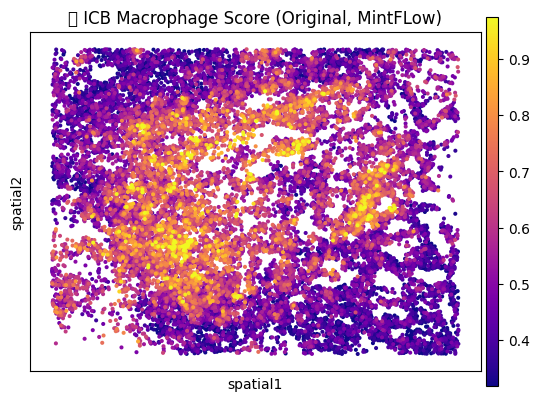

/tmp/ipykernel_3710465/309364085.py:25: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


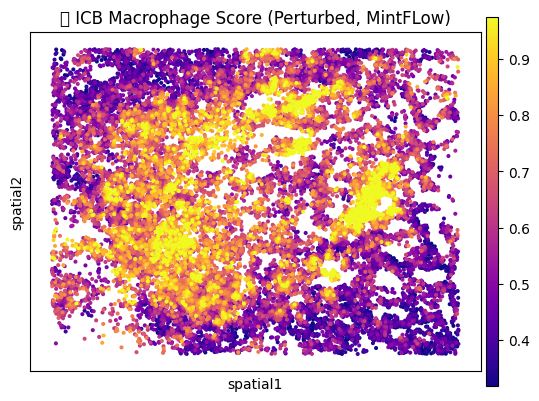

In [39]:
## GENERATE FIGURE 7C (with the same vmin/vmax in both plots)

vmin = min(
    adata_original.obs['ICB_macrophage_score'].quantile(0.05),
    adata_perturbed.obs['ICB_macrophage_score'].quantile(0.05)
)
vmax = max(
    adata_original.obs['ICB_macrophage_score'].quantile(0.95),
    adata_perturbed.obs['ICB_macrophage_score'].quantile(0.95)
)

sc.pl.spatial(
    adata_original,
    color='ICB_macrophage_score',
    cmap='plasma',  # Higher contrast than viridis
    spot_size=20,   # Slightly larger spots
    vmin=vmin,
    vmax=vmax,
    title='🔬 ICB Macrophage Score (Original, MintFLow)'
)

# vmin = adata_perturbed.obs['ICB_macrophage_score'].quantile(0.05)
# vmax = adata_perturbed.obs['ICB_macrophage_score'].quantile(0.95)

sc.pl.spatial(
    adata_perturbed,
    color='ICB_macrophage_score',
    cmap='plasma',
    spot_size=20,
    vmin=vmin,
    vmax=vmax,
    title='🔬 ICB Macrophage Score (Perturbed, MintFLow)'
)


✅ Score threshold (top 5%): 0.825
🔴 Original: 594 high-scoring cells
🟠 Perturbed: 2790 high-scoring cells


/tmp/ipykernel_3710465/464939263.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_3710465/464939263.py:52: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


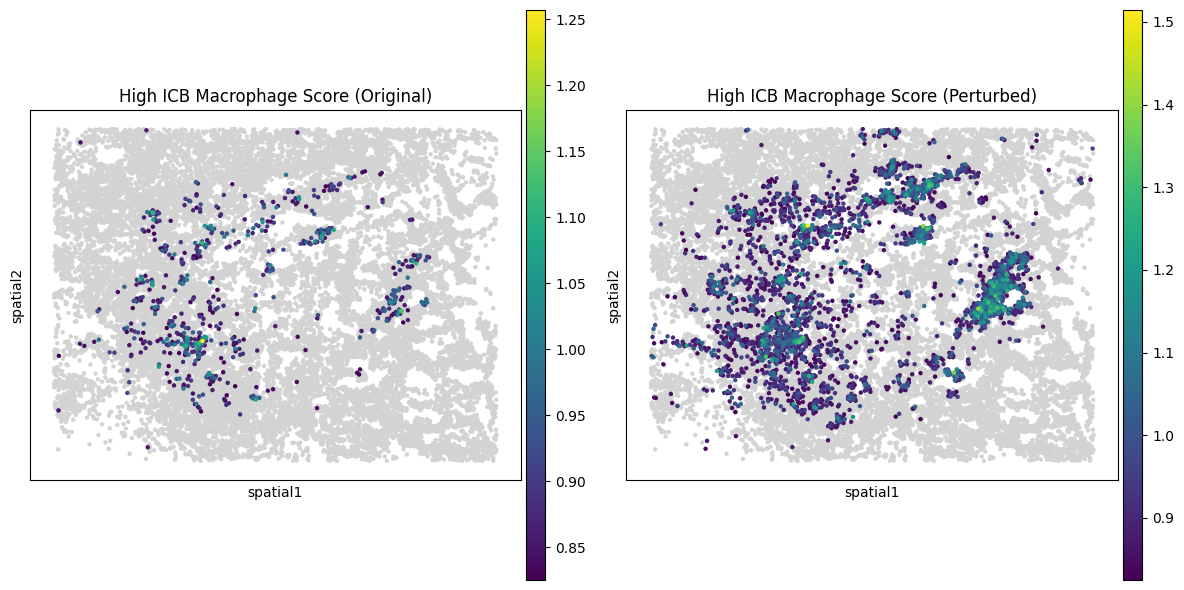

In [59]:
# Step 1: Create an ICB macrophage signature
macrophage_genes = ['VSIG4', 'CXCL9', 'SIGLEC10', 'FCGR1A', 'TMIGD3', 'NAPSB', 'CXCL10',
    'CALHM6', 'CD163', 'ASCL2', 'CLEC12A', 'SECTM1', 'SLAMF8', 'SCIMP',
    'CLEC4E', 'PTAFR', 'MNDA', 'ADORA3' 'FGL2', 'HLA-DQB2', 'ADAMDEC1', 'FBP1', 'ANKRD22', 'MARCO', 'IGSF6', 'HAMP'
]

# Step 2: Filter genes present in var_names
valid_genes = [g for g in macrophage_genes if g in adata_perturbed.var_names]
if not valid_genes:
    raise ValueError("None of the ICB genes are in var_names!")

gene_indices = [adata_perturbed.var_names.get_loc(g) for g in valid_genes]

# Step 3: Compute average MintFLow score per cell
adata_original.obs['ICB_macrophage_score'] = adata_original.obsm['MintFLow_Generated_Xmic'][:, gene_indices].mean(axis=1)
adata_perturbed.obs['ICB_macrophage_score'] = adata_perturbed.obsm['MintFLow_Generated_Xmic'][:, gene_indices].mean(axis=1)

# Step 1: Define shared threshold from both datasets
all_scores = pd.concat([
    adata_original.obs['ICB_macrophage_score'],
    adata_perturbed.obs['ICB_macrophage_score']
])
cutoff = np.percentile(all_scores, 90)
print(f"✅ Score threshold (top 5%): {cutoff:.3f}")

# Step 2: Mask all cells below threshold
for adata in [adata_original, adata_perturbed]:
    adata.obs['ICB_macrophage_score_high'] = adata.obs['ICB_macrophage_score'].where(
        adata.obs['ICB_macrophage_score'] >= cutoff, np.nan
    )

# Step 3: Count high-scoring cells in each
n_high_original = adata_original.obs['ICB_macrophage_score_high'].notna().sum()
n_high_perturbed = adata_perturbed.obs['ICB_macrophage_score_high'].notna().sum()
print(f"🔴 Original: {n_high_original} high-scoring cells")
print(f"🟠 Perturbed: {n_high_perturbed} high-scoring cells")

# Step 4: Plot both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sc.pl.spatial(
    adata_original,
    color='ICB_macrophage_score_high',
    cmap='viridis',
    spot_size=20,
    title='High ICB Macrophage Score (Original)',
    na_color='lightgrey',
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata_perturbed,
    color='ICB_macrophage_score_high',
    cmap='viridis',
    spot_size=20,
    title='High ICB Macrophage Score (Perturbed)',
    na_color='lightgrey',
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()


In [64]:

# Define the cell type of interest
cell_type = "Macrophage"

# Step 1: Build filters
row_filter_original = np.logical_and(
    adata_original.obs['level_2_cell_type_formintflow'] == cell_type,
    [dict_cellID_to_MCChaschanged.get(cid, False) for cid in adata_original.obs['cell_id']]
)

row_filter_perturbed = np.logical_and(
    adata_perturbed.obs['level_2_cell_type_formintflow'] == cell_type,
    [dict_cellID_to_MCChaschanged.get(cid, False) for cid in adata_perturbed.obs['cell_id']]
)

# Safety check: enough cells?
if row_filter_original.sum() < 2 or row_filter_perturbed.sum() < 2:
    raise ValueError("⚠️ Not enough valid macrophages for DE analysis.")

# Step 2: Build new AnnData object
X_combined = np.concatenate([
    adata_original.obsm['MintFLow_Generated_Xmic'][row_filter_original],
    adata_perturbed.obsm['MintFLow_Generated_Xmic'][row_filter_perturbed]
], axis=0)

obs_combined = pd.DataFrame({
    'perturbation_state': ['original'] * row_filter_original.sum() + ['perturbed'] * row_filter_perturbed.sum(),
    'cell_type': [cell_type] * (row_filter_original.sum() + row_filter_perturbed.sum())
})

adata_macrophage = sc.AnnData(
    X=X_combined,
    obs=obs_combined,
    var=adata_original.var.copy()
)


/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


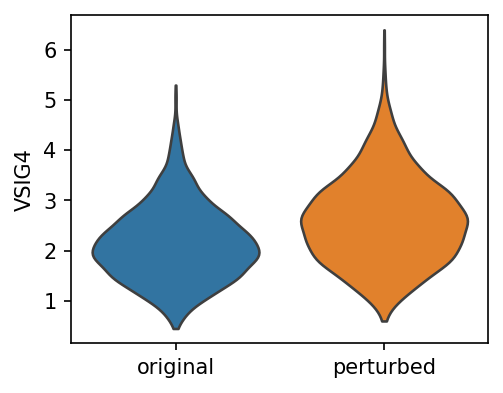

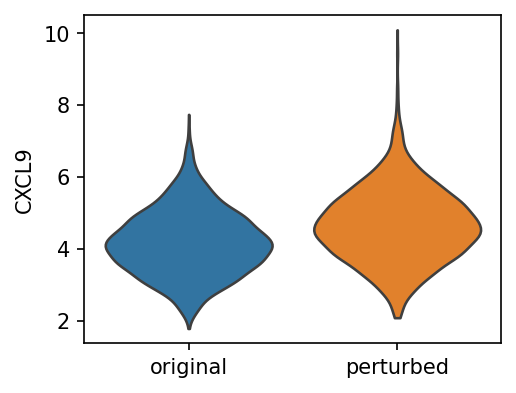

⚠️ Gene not found in var_names: SIGLEC10


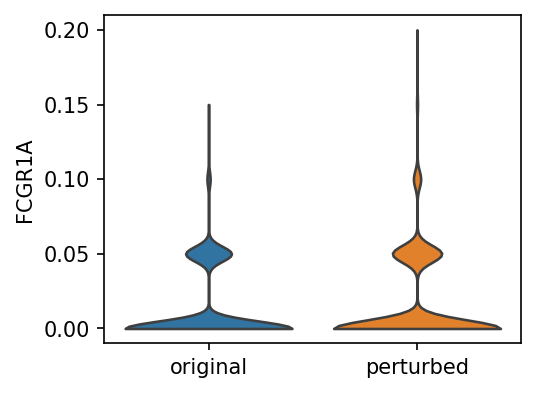

⚠️ Gene not found in var_names: TMIGD3
⚠️ Gene not found in var_names: NAPSB


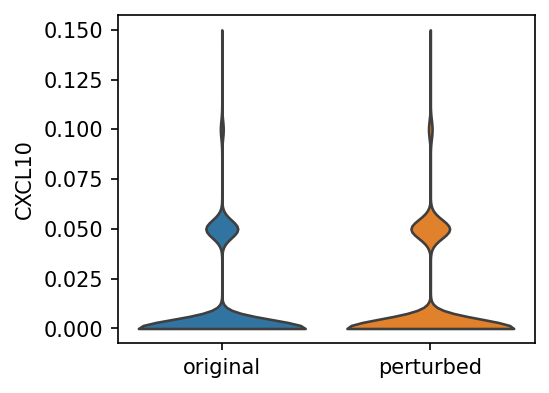

⚠️ Gene not found in var_names: CALHM6


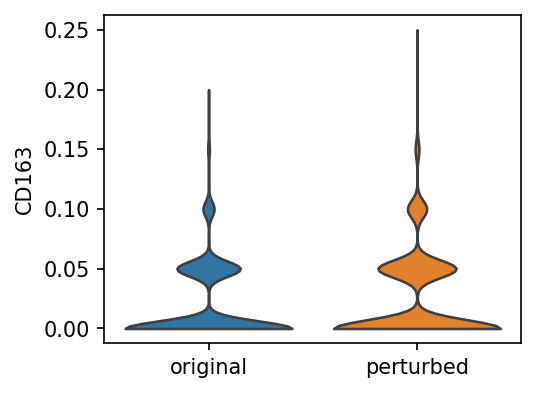

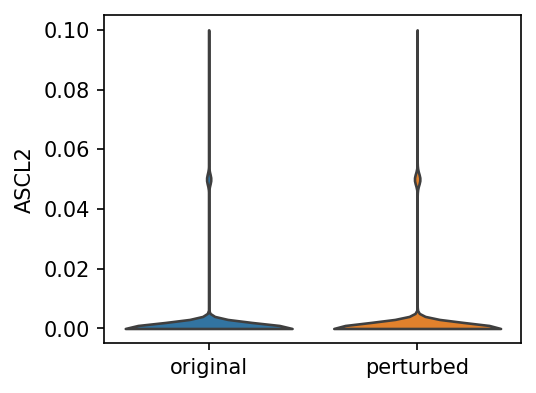

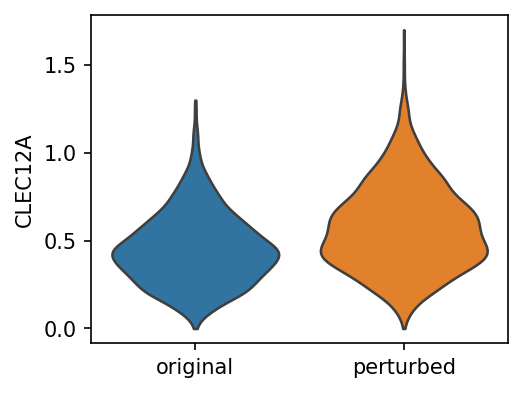

⚠️ Gene not found in var_names: SECTM1


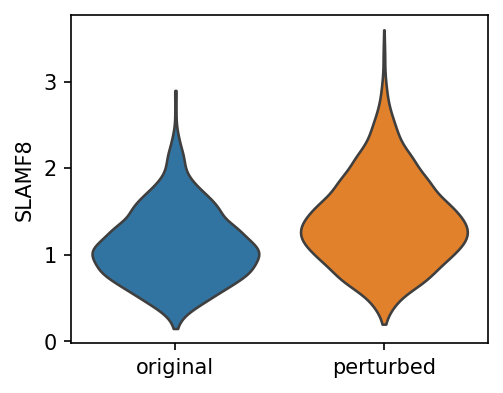

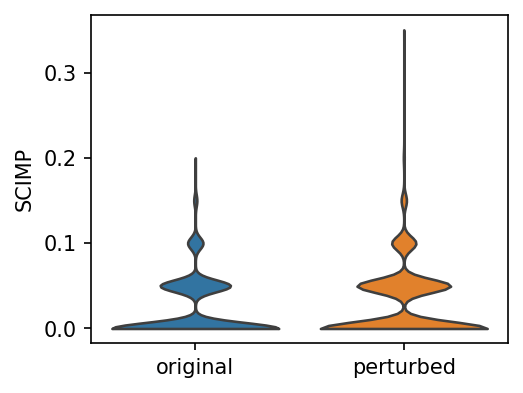

⚠️ Gene not found in var_names: CLEC4E


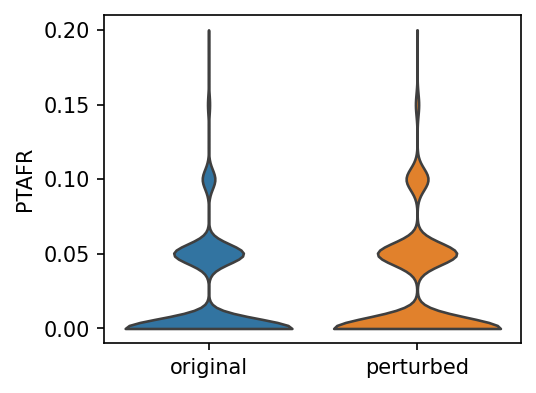

⚠️ Gene not found in var_names: MNDA
⚠️ Gene not found in var_names: ADORA3FGL2
⚠️ Gene not found in var_names: HLA-DQB2


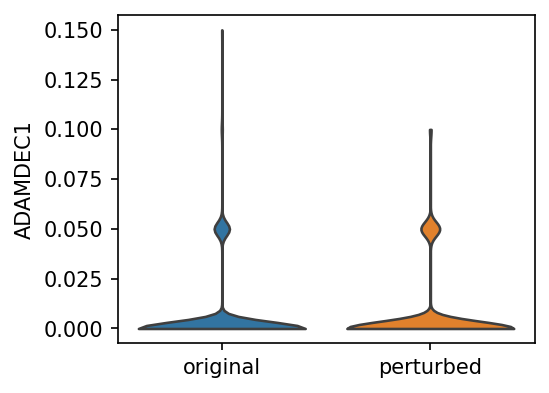

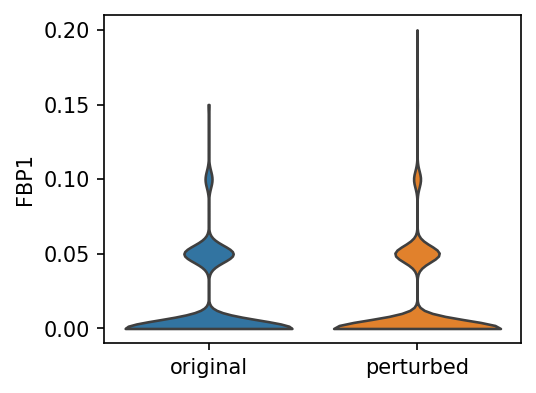

⚠️ Gene not found in var_names: ANKRD22


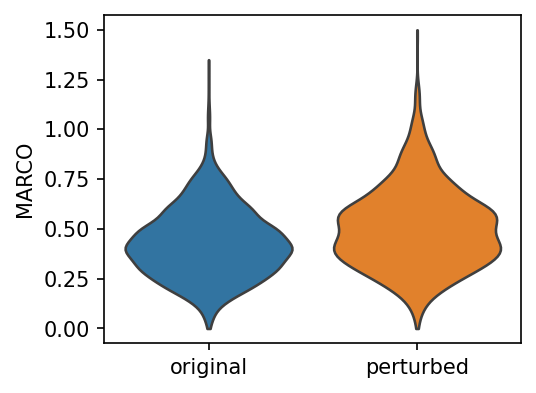

⚠️ Gene not found in var_names: IGSF6


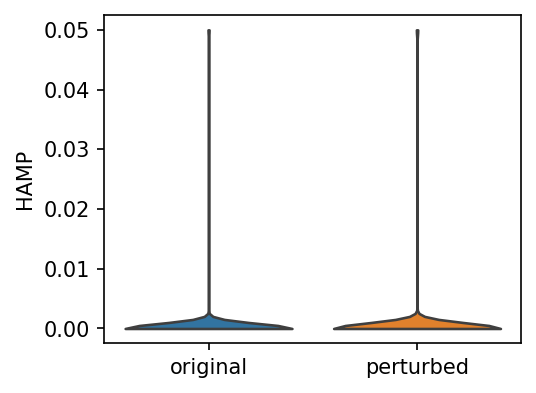

In [68]:
## GENERATE FIGURE SUPPLEMENTARY S14A

# Set figure size and DPI for export-quality plots
plt.rcParams["figure.figsize"] = (4, 3)
plt.rcParams["figure.dpi"] = 150

# Your selected macrophage genes
selected_genes = ['VSIG4', 'CXCL9', 'SIGLEC10', 'FCGR1A', 'TMIGD3', 'NAPSB', 'CXCL10',
    'CALHM6', 'CD163', 'ASCL2', 'CLEC12A', 'SECTM1', 'SLAMF8', 'SCIMP',
    'CLEC4E', 'PTAFR', 'MNDA', 'ADORA3' 'FGL2', 'HLA-DQB2', 'ADAMDEC1', 'FBP1', 'ANKRD22', 'MARCO', 'IGSF6', 'HAMP'
]

# Loop through genes and plot
for gene in selected_genes:
    if gene in adata_macrophage.var_names:
        sc.pl.violin(
            adata_macrophage,
            keys=gene,
            groupby='perturbation_state',
            stripplot=False,
            jitter=False,
            rotation=0,
            multi_panel=False,
            show=True,
            log=False
        )
    else:
        print(f"⚠️ Gene not found in var_names: {gene}")


In [ ]:
## GENERATE FIGURE SUPPLEMENTARY S14B

# Step 1: Run DE for macrophages
adata_macrophage.obs['perturbation_state'] = adata_macrophage.obs['perturbation_state'].astype('category')
sc.tl.rank_genes_groups(
    adata_macrophage,
    groupby='perturbation_state',
    method='wilcoxon',
    reference='original',
    key_added='rank_genes_macrophage'
)

# Step 2: Prepare gene list for GSEA
de_result = sc.get.rank_genes_groups_df(adata_macrophage, group='perturbed', key='rank_genes_macrophage')
de_result = de_result.dropna(subset=['names', 'scores'])
de_result = de_result.sort_values(by='scores', ascending=False)

# Remove duplicates and convert to proper format
rnk_df = de_result[['names', 'scores']].drop_duplicates(subset='names')
rnk_df.columns = ['gene_name', 'score']
rnk_df = rnk_df.set_index('gene_name')

# Step 3: Run preranked GSEA
gsea_results = gp.prerank(
    rnk=rnk_df,
    gene_sets='GO_Biological_Process_2021',  # You can change this
    threads=4,
    permutation_num=100,
    outdir=None,
    seed=42,
    min_size=10,
    max_size=500
)

# Step 4: Inspect result and find correct column for significance
print("GSEA result columns:", gsea_results.res2d.columns)

# Step 5: Bar plot using available column name (usually 'FDR q-val')
fig = barplot(
    gsea_results.res2d,
    title='Macrophage: GSEA (Perturbed vs Original)',
    column='FDR q-val',   # Adjusted P-value column name may vary!
    cutoff=0.05,
    top_term=10,
    figsize=(7, 5)
)

plt.tight_layout()
plt.show()


2025-07-21 21:28:17,242 [WARNING] Duplicated values found in preranked stats: 8.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
